In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

df = pd.read_csv('Dataset/bank-full.csv',sep=';')

df_numerica = df[['age','balance','duration','campaign','pdays','previous','y']]

Bernoulli-Naive-Bayes

In [2]:
df_binaria = df[['default','housing','loan','y']]

map_bin = {'yes':1,'no':0}
df_binaria = df_binaria.replace(map_bin)

display(df_binaria.sample(5))

C:\Users\User\AppData\Local\Temp\ipykernel_6984\3530678058.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_binaria = df_binaria.replace(map_bin)


,default,housing,loan,y
30424,0,0,1,0
41138,0,0,0,0
16423,0,1,1,0
14077,0,1,0,0
19285,0,0,0,1


A acurácia do modelo Bernoulli-Naive-Bayes foi de 64.14%


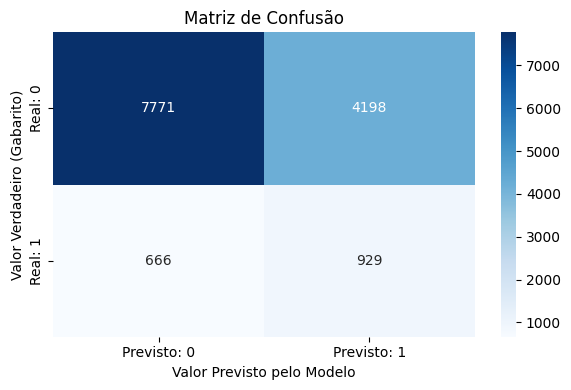

In [3]:
Y = df_binaria['y']
X = df_binaria.drop(columns=['y'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

rus = RandomUnderSampler(random_state=0)
X_train_balanceado, y_train_balanceado = rus.fit_resample(X_train, y_train)
#display(y_train_balanceado.value_counts())

modelo = BernoulliNB()

modelo.fit(X_train_balanceado,y_train_balanceado)

Y_predict = modelo.predict(X_test)

accuracy = accuracy_score(y_test,Y_predict)
print(f'A acurácia do modelo Bernoulli-Naive-Bayes foi de {accuracy*100:.2f}%')

matriz_c = confusion_matrix(y_test,Y_predict)
#print(matriz_c)

plt.figure(figsize=(6, 4))
# annot=True mostra os números, fmt='d' garante que sejam inteiros
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

Isto é, o fato de que a pessoa está devendo ou não, ou se ela tem ou não algum empréstimo não carrega muita informação sobre o fato de que ela vai ou não contratar o serviço.